In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('../data/processed/aa_dfw_scoped.csv', low_memory=False)
print(df.shape)
df.head()

(555604, 26)


,YEAR,MONTH,DAY_OF_MONTH,FL_DATE,REPORTING_AIRLINE,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2023,1,10,2023-01-10,AA,AUS,"Austin, TX",DFW,"Dallas/Fort Worth, TX",630,616.0,-14.0,739,719.0,-20.0,0.0,NaN,0.0,69.0,63.0,190.0,NaN,NaN,NaN,NaN,NaN
1,2023,1,2,2023-01-02,AA,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",1200,1154.0,-6.0,1324,1331.0,7.0,0.0,NaN,0.0,204.0,217.0,1235.0,NaN,NaN,NaN,NaN,NaN
2,2023,1,2,2023-01-02,AA,LAX,"Los Angeles, CA",DFW,"Dallas/Fort Worth, TX",1730,1725.0,-5.0,2231,2252.0,21.0,0.0,NaN,0.0,181.0,207.0,1235.0,0.0,0.0,21.0,0.0,0.0
3,2023,1,2,2023-01-02,AA,DFW,"Dallas/Fort Worth, TX",SFO,"San Francisco, CA",2125,2249.0,84.0,2317,57.0,100.0,0.0,NaN,0.0,232.0,248.0,1464.0,68.0,0.0,16.0,0.0,16.0
4,2023,1,4,2023-01-04,AA,MIA,"Miami, FL",DFW,"Dallas/Fort Worth, TX",942,1117.0,95.0,1203,1452.0,169.0,0.0,NaN,0.0,201.0,275.0,1121.0,78.0,0.0,74.0,0.0,17.0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (555604, 26)

Columns:
['YEAR', 'MONTH', 'DAY_OF_MONTH', 'FL_DATE', 'REPORTING_AIRLINE', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

Data types:
YEAR                     int64
MONTH                    int64
DAY_OF_MONTH             int64
FL_DATE                 object
REPORTING_AIRLINE       object
ORIGIN                  object
ORIGIN_CITY_NAME        object
DEST                    object
DEST_CITY_NAME          object
CRS_DEP_TIME             int64
DEP_TIME               float64
DEP_DELAY              float64
CRS_ARR_TIME             int64
ARR_TIME               float64
ARR_DELAY              float64
CANCELLED              float64
CANCELLATION_CODE       object
DIVERTED               float64
CRS_EL

In [5]:
print("Unique airlines:", df['OP_UNIQUE_CARRIER'].unique() if 'OP_UNIQUE_CARRIER' in df.columns else "Column missing")
print("Unique origin airports:", df['ORIGIN'].nunique() if 'ORIGIN' in df.columns else "Column missing")
print("Unique destination airports:", df['DEST'].nunique() if 'DEST' in df.columns else "Column missing")

Unique airlines: Column missing
Unique origin airports: 34
Unique destination airports: 34


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

missing_df.head(20)

,missing_count,missing_percent
CANCELLATION_CODE,543674,97.852787
LATE_AIRCRAFT_DELAY,405716,73.022512
SECURITY_DELAY,405716,73.022512
NAS_DELAY,405716,73.022512
WEATHER_DELAY,405716,73.022512
CARRIER_DELAY,405716,73.022512
ARR_DELAY,13754,2.475504
ACTUAL_ELAPSED_TIME,13754,2.475504
ARR_TIME,11977,2.155672
DEP_DELAY,11558,2.080259


In [7]:
df['CANCELLED'] = df['CANCELLED'].fillna(0).astype(int)
df['DIVERTED']  = df['DIVERTED'].fillna(0).astype(int)

In [8]:
operated = df['CANCELLED'] == 0
print("Operated flights:", operated.sum())
print("Cancelled flights:", (df['CANCELLED'] == 1).sum())

Operated flights: 543674
Cancelled flights: 11930


In [9]:
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
              'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

for col in cause_cols:
    if col in df.columns:
        df.loc[operated, col] = df.loc[operated, col].fillna(0)
# Leave delay-cause columns as NaN for cancelled flights — that's correct

In [10]:
for col in ['ARR_DELAY', 'DEP_DELAY']:
    if col in df.columns:
        median_val = df.loc[operated, col].median()
        df.loc[operated, col] = df.loc[operated, col].fillna(median_val)

In [11]:
# Do NOT fill CANCELLATION_CODE — keep it as NaN for non-cancelled flights
df['WEATHER_CANCELLED'] = (
    (df['CANCELLED'] == 1) & (df['CANCELLATION_CODE'] == 'B')
).astype(int)

print("Weather cancellations:", df['WEATHER_CANCELLED'].sum())

Weather cancellations: 10518


In [12]:
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

DEP_TIME                11558
DEP_DELAY               11558
ARR_TIME                11977
ARR_DELAY               11930
CANCELLATION_CODE      543674
ACTUAL_ELAPSED_TIME     13754
CARRIER_DELAY           11930
WEATHER_DELAY           11930
NAS_DELAY               11930
SECURITY_DELAY          11930
LATE_AIRCRAFT_DELAY     11930
dtype: int64


In [13]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
df['SEASON'] = df['MONTH'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})
df['HAS_WEATHER_DELAY']  = (df['WEATHER_DELAY'] > 0).astype(int)
df['IS_DELAYED_15']      = (df['ARR_DELAY'] > 15).astype(int)
df['DFW_DIRECTION']      = df['DEST'].apply(
    lambda x: 'Inbound_to_DFW' if x == 'DFW' else 'Outbound_from_DFW'
)

In [14]:
df.to_csv('../data/processed/aa_dfw_cleaned_day2.csv', index=False)
print("✅ Cleaned file saved!")
print(df.shape)


✅ Cleaned file saved!
(555604, 31)


C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\3349367069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_counts, x='MONTH', y='flight_count', palette='Blues_d')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart1_monthly_flight_count.png'

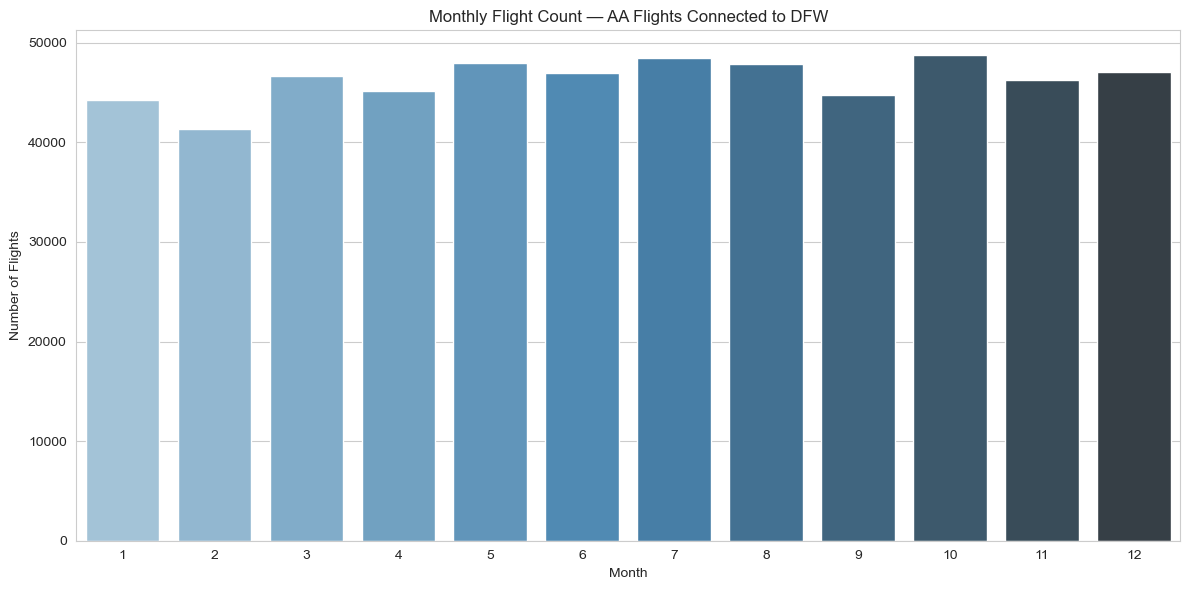

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

monthly_counts = df.groupby('MONTH').size().reset_index(name='flight_count')

sns.barplot(data=monthly_counts, x='MONTH', y='flight_count', palette='Blues_d')
plt.title('Monthly Flight Count — AA Flights Connected to DFW')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.savefig('../report/chart1_monthly_flight_count.png', dpi=200)
plt.show()

C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\338390581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_weather, x='MONTH', y='WEATHER_DELAY', palette='Reds')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart2_monthly_weather_delay.png'

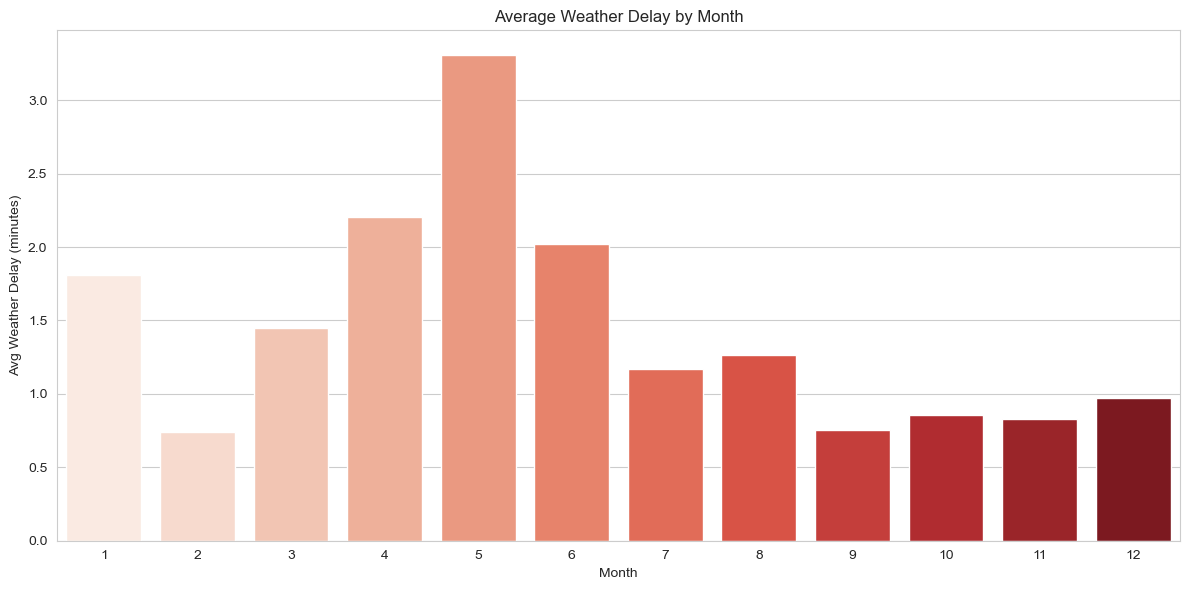

In [16]:
monthly_weather = df.groupby('MONTH')['WEATHER_DELAY'].mean().reset_index()

sns.barplot(data=monthly_weather, x='MONTH', y='WEATHER_DELAY', palette='Reds')
plt.title('Average Weather Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg Weather Delay (minutes)')
plt.tight_layout()
plt.savefig('../report/chart2_monthly_weather_delay.png', dpi=200)
plt.show()

C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\1877202950.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_weather, x='WEATHER_DELAY', y='ORIGIN', palette='rocket')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart3_top_weather_airports.png'

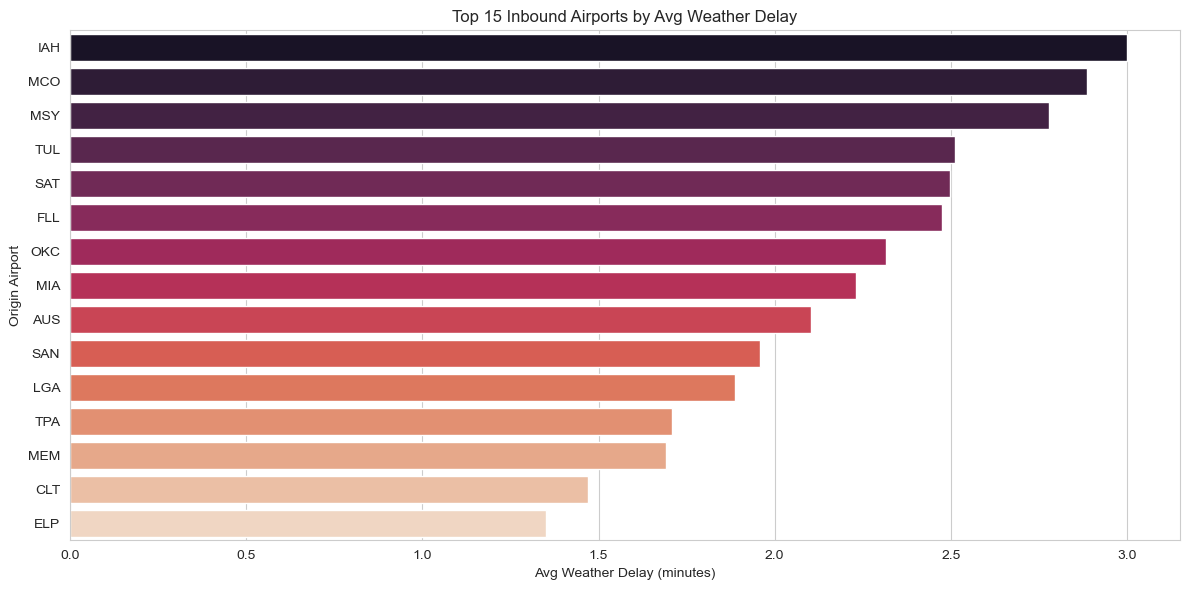

In [17]:
inbound_df = df[df['DEST'] == 'DFW'].copy()

top_weather = (
    inbound_df.groupby('ORIGIN')['WEATHER_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

sns.barplot(data=top_weather, x='WEATHER_DELAY', y='ORIGIN', palette='rocket')
plt.title('Top 15 Inbound Airports by Avg Weather Delay')
plt.xlabel('Avg Weather Delay (minutes)')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.savefig('../report/chart3_top_weather_airports.png', dpi=200)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../report/chart4_cancellation_rate.png'

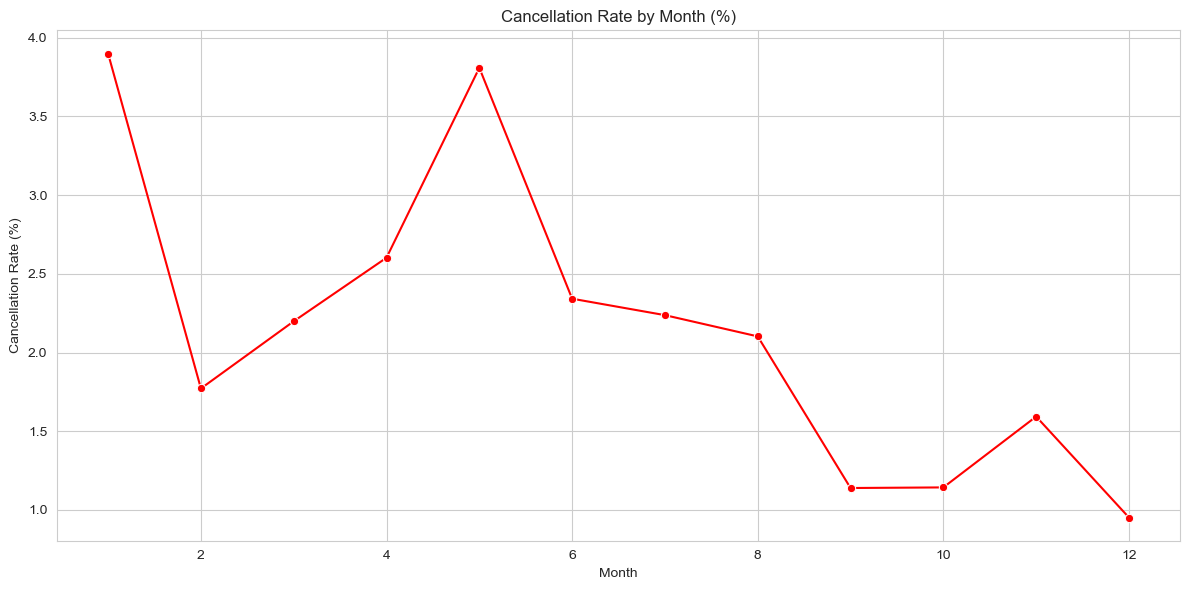

In [18]:
cancel_month = df.groupby('MONTH')['CANCELLED'].mean().reset_index()
cancel_month['CANCELLED'] = cancel_month['CANCELLED'] * 100

sns.lineplot(data=cancel_month, x='MONTH', y='CANCELLED', marker='o', color='red')
plt.title('Cancellation Rate by Month (%)')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.savefig('../report/chart4_cancellation_rate.png', dpi=200)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../report/chart5_arrival_delay_dist.png'

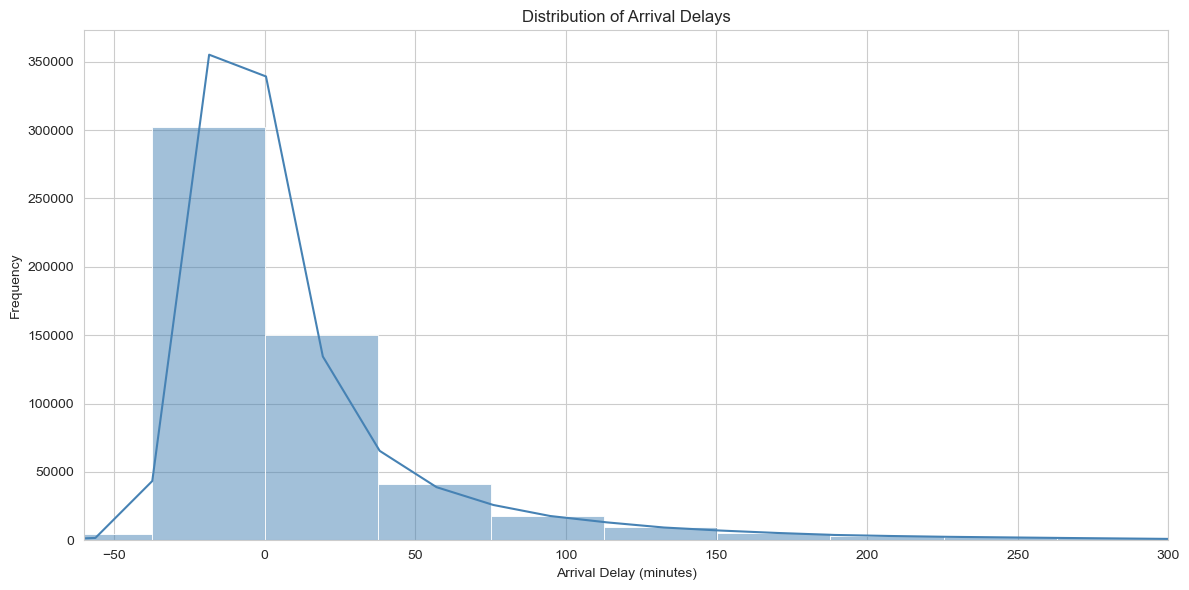

In [19]:
sns.histplot(df['ARR_DELAY'].dropna(), bins=100, kde=True, color='steelblue')
plt.xlim(-60, 300)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../report/chart5_arrival_delay_dist.png', dpi=200)
plt.show()

C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\1428334869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=direction_delay, x='DFW_DIRECTION', y='ARR_DELAY', palette='viridis')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart6_inbound_outbound.png'

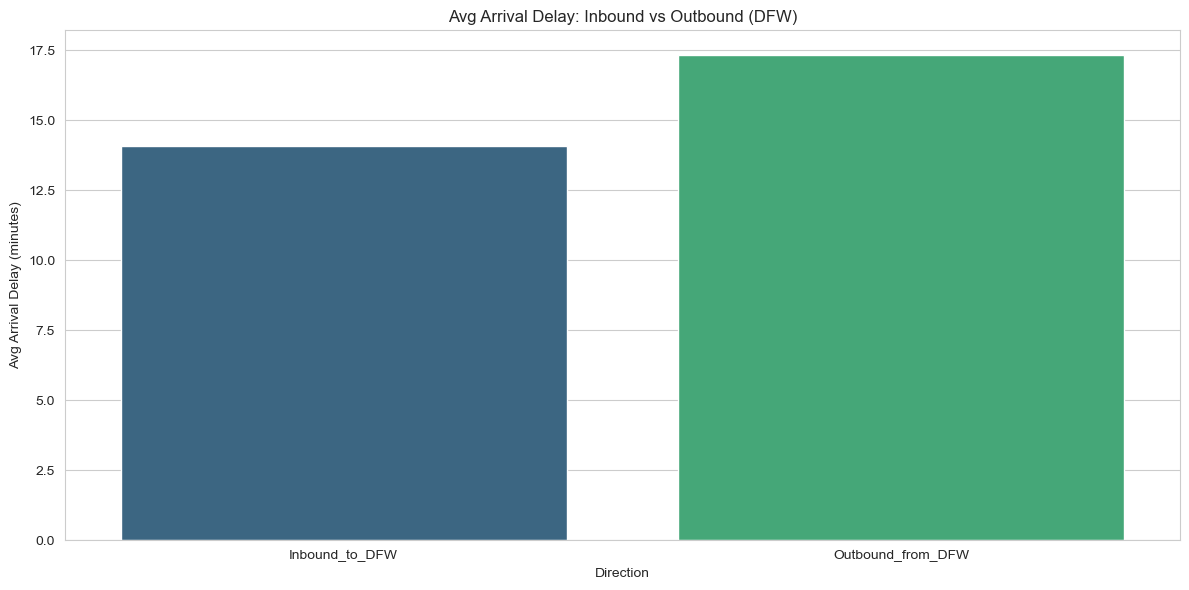

In [20]:
direction_delay = df.groupby('DFW_DIRECTION')['ARR_DELAY'].mean().reset_index()

sns.barplot(data=direction_delay, x='DFW_DIRECTION', y='ARR_DELAY', palette='viridis')
plt.title('Avg Arrival Delay: Inbound vs Outbound (DFW)')
plt.xlabel('Direction')
plt.ylabel('Avg Arrival Delay (minutes)')
plt.tight_layout()
plt.savefig('../report/chart6_inbound_outbound.png', dpi=200)
plt.show()

C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\2508435337.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_weather, x='SEASON', y='WEATHER_DELAY', palette='coolwarm')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart7_season_weather_delay.png'

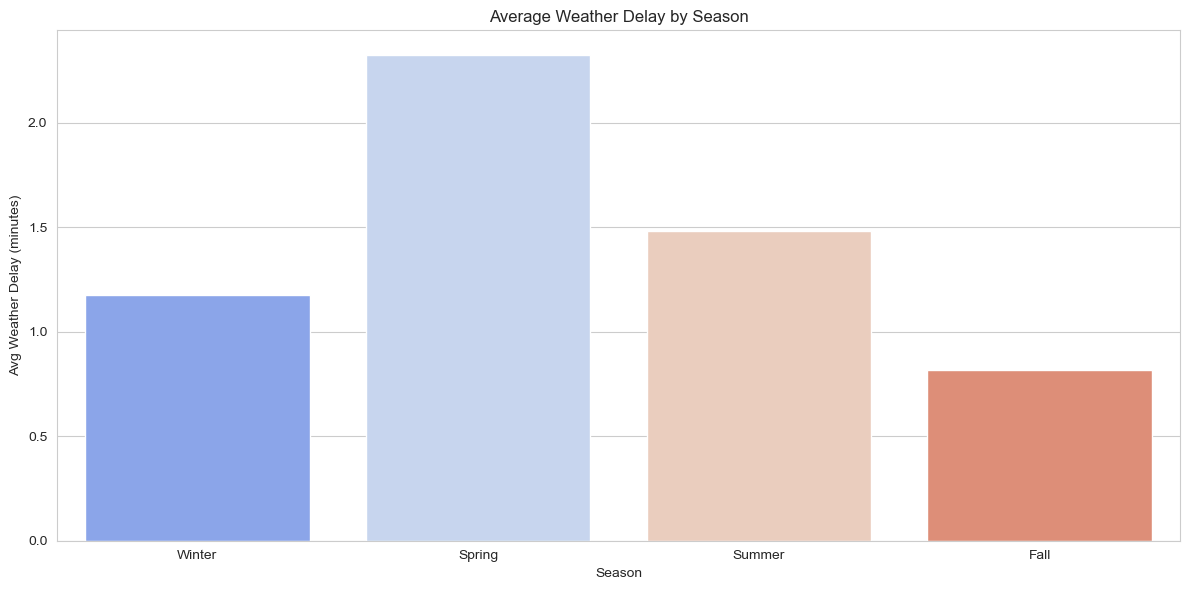

In [21]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_weather = df.groupby('SEASON')['WEATHER_DELAY'].mean().reset_index()
season_weather['SEASON'] = pd.Categorical(season_weather['SEASON'], categories=season_order, ordered=True)
season_weather = season_weather.sort_values('SEASON')

sns.barplot(data=season_weather, x='SEASON', y='WEATHER_DELAY', palette='coolwarm')
plt.title('Average Weather Delay by Season')
plt.xlabel('Season')
plt.ylabel('Avg Weather Delay (minutes)')
plt.tight_layout()
plt.savefig('../report/chart7_season_weather_delay.png', dpi=200)
plt.show()

C:\Users\chowd\AppData\Local\Temp\ipykernel_15508\2592281764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airport_cancel, x='CANCELLED', y='ORIGIN', palette='magma')


FileNotFoundError: [Errno 2] No such file or directory: '../report/chart8_top_cancel_airports.png'

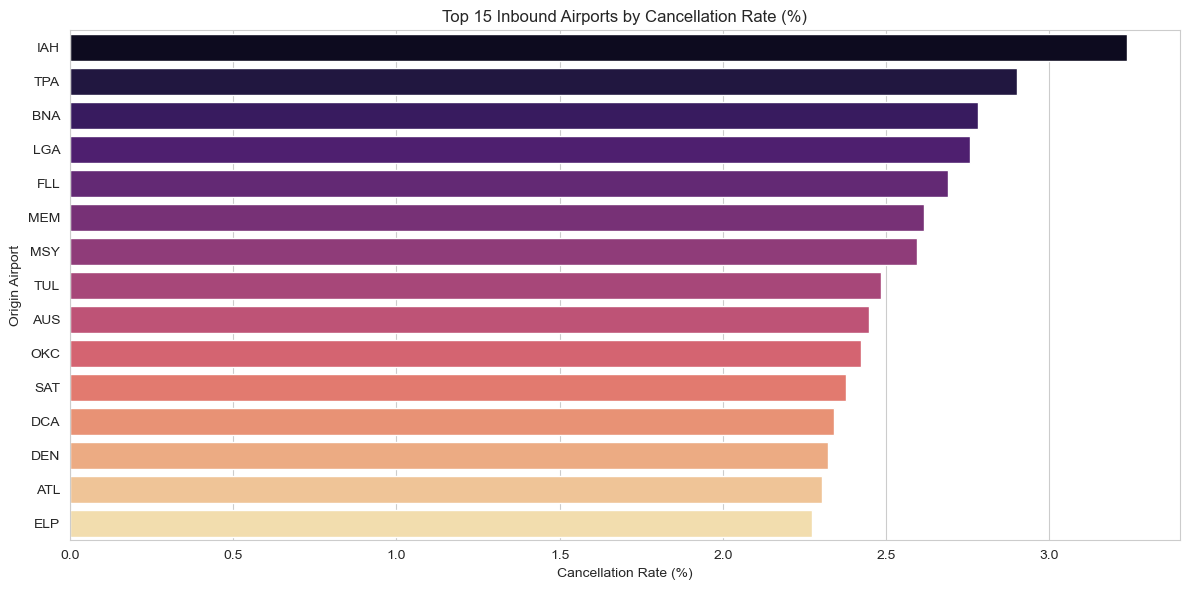

In [22]:
airport_cancel = (
    inbound_df.groupby('ORIGIN')['CANCELLED']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
airport_cancel['CANCELLED'] = airport_cancel['CANCELLED'] * 100

sns.barplot(data=airport_cancel, x='CANCELLED', y='ORIGIN', palette='magma')
plt.title('Top 15 Inbound Airports by Cancellation Rate (%)')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.savefig('../report/chart8_top_cancel_airports.png', dpi=200)
plt.show()

In [23]:
# Build airport-month summary (feeds into Day 3)
airport_summary = inbound_df.groupby(['ORIGIN', 'MONTH']).agg(
    total_flights=('FL_DATE', 'count'),
    avg_arr_delay=('ARR_DELAY', 'mean'),
    avg_weather_delay=('WEATHER_DELAY', 'mean'),
    weather_delay_flights=('HAS_WEATHER_DELAY', 'sum'),
    cancelled_flights=('CANCELLED', 'sum')
).reset_index()

airport_summary['weather_delay_rate'] = (
    airport_summary['weather_delay_flights'] / airport_summary['total_flights']
)
airport_summary['cancel_rate'] = (
    airport_summary['cancelled_flights'] / airport_summary['total_flights']
)

airport_summary.to_csv('../data/processed/airport_month_summary_day2.csv', index=False)
print("✅ Airport summary saved!")
print(airport_summary.shape)
print(airport_summary.head(10))

✅ Airport summary saved!
(396, 9)
  ORIGIN  MONTH  total_flights  avg_arr_delay  avg_weather_delay  \
0    ATL      1            585      15.885510           2.992844   
1    ATL      2            543       6.238274           0.151970   
2    ATL      3            627      12.374384           0.970443   
3    ATL      4            614      18.720067           1.671164   
4    ATL      5            654      22.370607           1.630990   
5    ATL      6            692      24.161243           1.218935   
6    ATL      7            710      30.143885           0.674820   
7    ATL      8            707      19.750000           0.917630   
8    ATL      9            653      10.955039           0.787597   
9    ATL     10            698       6.807803           0.697977   

   weather_delay_flights  cancelled_flights  weather_delay_rate  cancel_rate  
0                     15                 26            0.025641     0.044444  
1                      7                 10            0.01